In [ ]:
import pandas as pd
import polars as pl
from plotnine import *

from polars import col, lit

import plotly.express as px

In [29]:
df_mu = pl.read_csv("Data/Monthly_Listeners.txt", separator="\t")
df_du = pl.read_csv("Data/Daily_Listeners.txt", separator="\t")

df_mu = (
    df_mu.with_columns(
        (
            pl.col("Year").cast(pl.Utf8) 
            + "-" 
            + pl.col("Month").cast(pl.Utf8).str.zfill(2)
        )
        .alias("YearMonth")
    )
    .rename({"Listeners": "NumListeners"})
)

df_du = (
    df_du.with_columns(
        # col("day").str.split_exact(by="/", n=2).alias("split")
        col("day").str.split("/").list.to_struct(fields=["Month", "Day", "Year"]).alias("unpacked")
    )
    .unnest("unpacked")
    .with_columns(
        (lit("20") + col("Year")).alias("Year"),
    )
    .with_columns(
        col("Month", "Day", "Year").cast(pl.Int64),
        col("day").str.to_date("%m/%d/%y").alias("Date")
    )
    .with_columns(
        pl.col("Date").dt.weekday().alias("DayOfWeek"),
        pl.col("Date").dt.strftime("%A").alias("DayOfWeekStr"),
    )
    .rename({
        "day": "DayStr",
        "platform": "Platform",
        "listeners": "NumListeners", 
    })
)

display(df_du, df_mu, )


DayStr,Platform,NumListeners,Month,Day,Year,Date,DayOfWeek,DayOfWeekStr
str,str,f64,i64,i64,i64,date,i8,str
"""1/1/18""","""Android""",4.8551e6,1,1,2018,2018-01-01,1,"""Monday"""
"""1/1/18""","""Roku""",460272.1429,1,1,2018,2018-01-01,1,"""Monday"""
"""1/1/18""","""All_Other""",898116.4286,1,1,2018,2018-01-01,1,"""Monday"""
"""1/1/18""","""Web""",481056.4286,1,1,2018,2018-01-01,1,"""Monday"""
"""1/1/18""","""Amazon""",410797.1429,1,1,2018,2018-01-01,1,"""Monday"""
…,…,…,…,…,…,…,…,…
"""12/31/20""","""Amazon""",263373.3,12,31,2020,2020-12-31,4,"""Thursday"""
"""12/31/20""","""Android""",5701804.2,12,31,2020,2020-12-31,4,"""Thursday"""
"""12/31/20""","""All_Other""",1824875.1,12,31,2020,2020-12-31,4,"""Thursday"""


Year,Month,Platform,NumListeners,YearMonth
i64,i64,str,f64,str
2018,9,"""Amazon""",2.1164e6,"""2018-09"""
2018,7,"""All_Other""",4.8963e6,"""2018-07"""
2018,1,"""Web""",8.1500e6,"""2018-01"""
2018,11,"""iOS""",2.6937e7,"""2018-11"""
2018,1,"""All_Other""",5.0546e6,"""2018-01"""
…,…,…,…,…
2020,8,"""Android""",1.7825e7,"""2020-08"""
2020,2,"""iOS""",3.0595e7,"""2020-02"""
2020,8,"""Roku""",2938621.5,"""2020-08"""


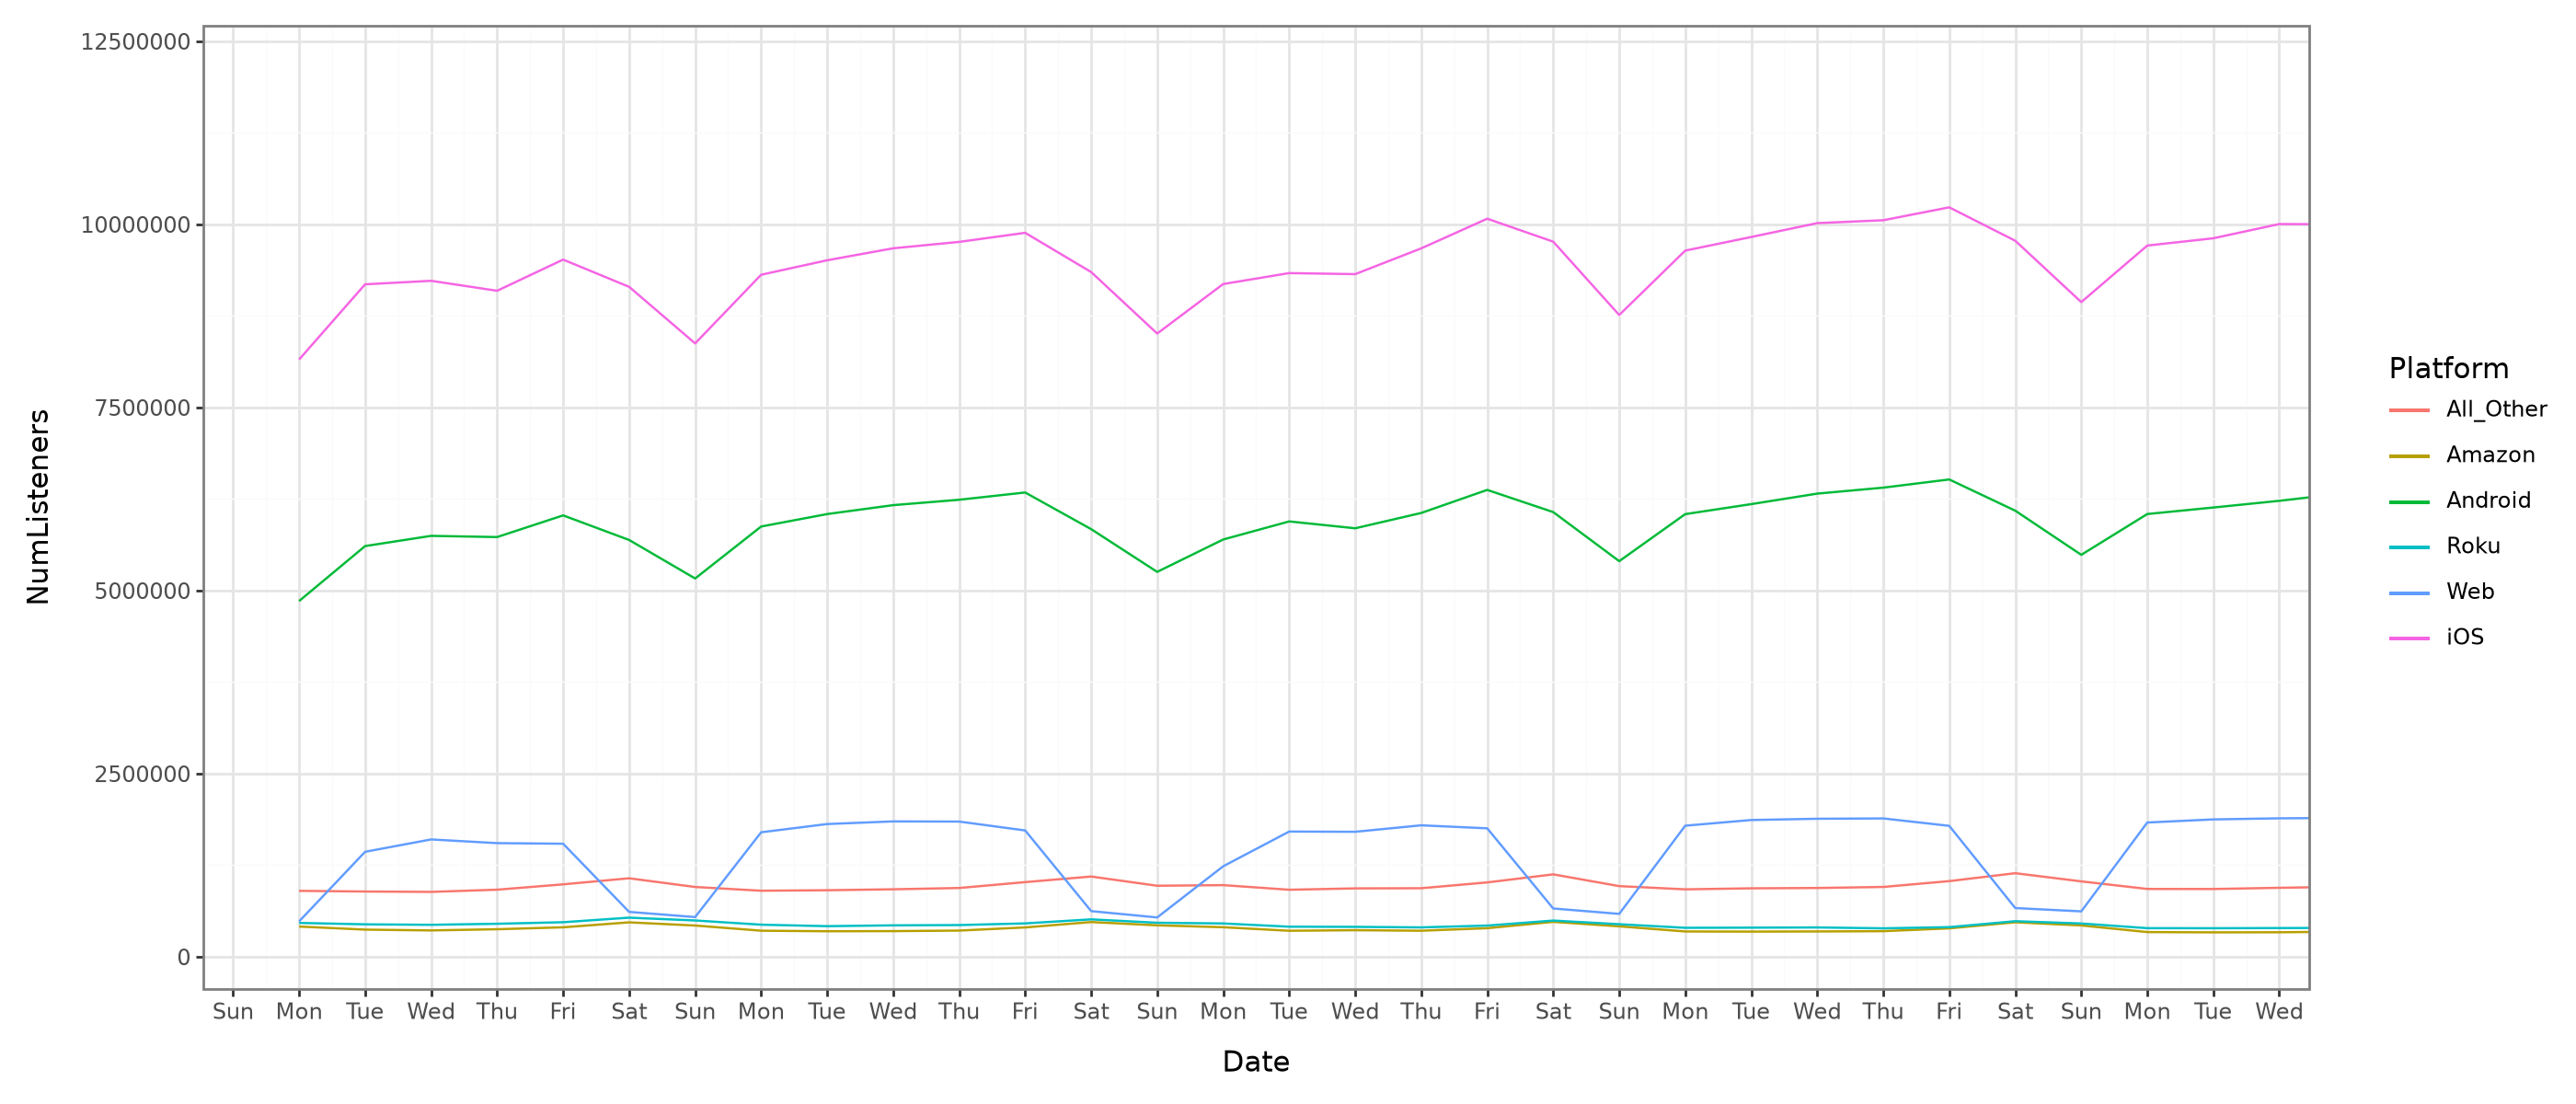

In [31]:
(
    ggplot(data=df_du, mapping=aes(x="Date", y="NumListeners", fill="Platform", color="Platform"))
    + geom_line()
    + scale_x_date(date_breaks="1 day", date_labels="%a")
    + coord_cartesian(xlim=[pd.to_datetime("2018-01-01"), pd.to_datetime("2018-01-30")])
    + theme_bw()
    + theme(
       figure_size=[14, 6] 
    )
)

Platform,DayOfWeek,DayOfWeekStr,NumListeners
str,i8,str,f64
"""Amazon""",7,"""Sunday""",441909.842029
"""iOS""",2,"""Tuesday""",1.0476e7
"""iOS""",4,"""Thursday""",1.0637e7
"""Android""",6,"""Saturday""",5.9098e6
"""Android""",3,"""Wednesday""",6.0649e6
…,…,…,…
"""Roku""",5,"""Friday""",502778.563828
"""Roku""",2,"""Tuesday""",478770.670883
"""Amazon""",1,"""Monday""",382516.84067


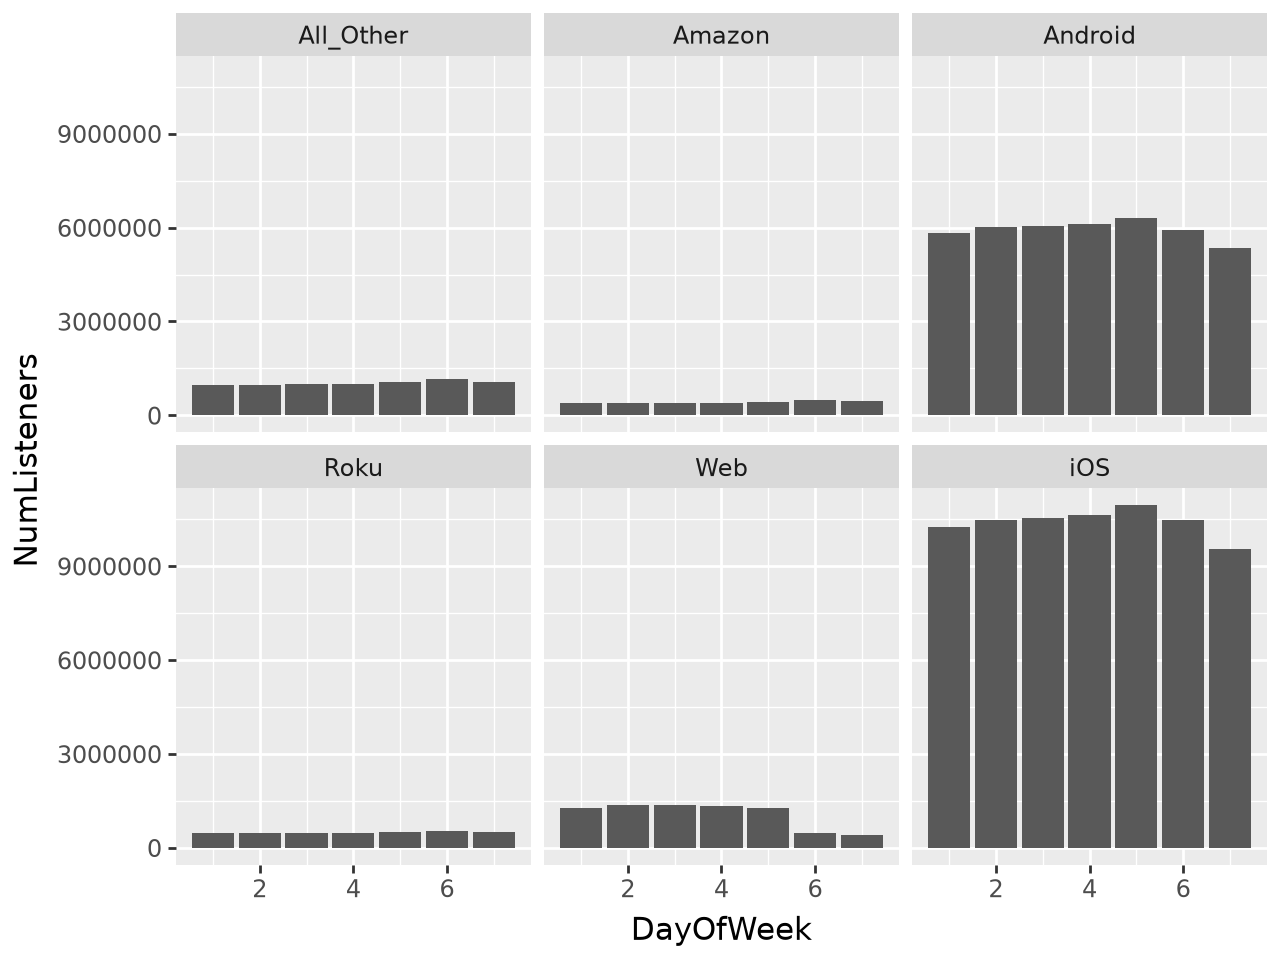

In [39]:
(
    df_du.group_by("DayOfWeekStr")
    .agg(col("NumListeners").mean())
)

df_du_by_day_of_week = (
    df_du.group_by("Platform", "DayOfWeek", "DayOfWeekStr")
    .agg(col("NumListeners").mean())
)

display(df_du_by_day_of_week)
(
    ggplot(data=df_du_by_day_of_week, mapping=aes(x="DayOfWeek", y="NumListeners"))
    + facet_wrap("Platform")
    + geom_col()
)

In [ ]:

# Sort so bars stack/order correctly along the x-axis
df_mu = df_mu.sort(["Year", "Month"])
display(df_mu)
# Create stacked bar chart
fig = px.bar(
    df_mu,
    x="YearMonth",
    y="NumListeners",
    color="Platform",
    category_orders={"Platform": ["iOS", "Android",  "Web", "All_Other", "Roku", "Amazon",]}
)

fig.update_layout(
    barmode="stack", 
    bargap=0,
    xaxis_title="Year-Month", 
    yaxis_title="NumListeners",
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="lightgray",
    gridwidth=1,
    griddash="dot",
    layer="above traces",
)

fig.show()

Year,Month,Platform,NumListeners,YearMonth
i64,i64,str,f64,str
2018,1,"""Web""",8.1500e6,"""2018-01"""
2018,1,"""All_Other""",5.0546e6,"""2018-01"""
2018,1,"""Roku""",2.07789e6,"""2018-01"""
2018,1,"""Android""",1.8729e7,"""2018-01"""
2018,1,"""iOS""",2.7803e7,"""2018-01"""
…,…,…,…,…
2020,12,"""Android""",1.7230e7,"""2020-12"""
2020,12,"""Roku""",3399923.7,"""2020-12"""
2020,12,"""All_Other""",8201977.2,"""2020-12"""


In [26]:
fig.update_yaxes(
    range=[55_000_000, 70_000_000]
)

fig.show()

In [27]:
fig.write_html(
    "test_plot.html",
    include_plotlyjs="cdn",
    full_html=True
)